In [32]:
import pandas as pd
import matplotlib.pyplot as plt

In [33]:
df_cursos_prouni = pd.read_csv(r'C:\Users\paulo\Desktop\pythonAnalise\analise\projeto9\data\cursos_prouni.csv', sep= ',')
df_enderecos_campi = pd.read_csv(r'C:\Users\paulo\Desktop\pythonAnalise\analise\projeto9\data\enderecos_campi.csv', sep= ',')

In [34]:
df_unido = pd.merge(df_cursos_prouni , df_enderecos_campi, left_on='campus_id', right_on= 'id',  how='outer')

pd.set_option("display.max_columns", None)

df_unido.to_csv('base_prouni_tratada.csv', sep= ';', index=False, encoding='utf-8-sig')


•	Missão 1 (O Merge e Limpeza): Fazer a leitura dos dois CSVs usando pd.read_csv() e uni-los com pd.merge(). Tratar os valores nulos (NaN) da coluna nota_integral_ampla.

In [35]:
df_unido = df_unido.fillna(0)

df_unido.head()

,grau,turno,mensalidade,bolsa_integral_cotas,bolsa_integral_ampla,bolsa_parcial_cotas,bolsa_parcial_ampla,curso_id,curso_busca,cidade_busca,uf_busca,cidade_filtro,universidade_nome,campus_nome,campus_id,nome,nota_integral_ampla,nota_integral_cotas,nota_parcial_ampla,nota_parcial_cotas,uf,municipio,logradouro,complemento,bairro,telefone,id
0,Bacharelado,Integral,6252.54,1.0,4.0,0.0,0.0,22413994854,Medicina,Erechim,RS,NDMwMTAwNDA3MDA1,Universidade Regional Integrada do Alto Urugua...,CAMPUS DE ERECHIM - Centro,224,Medicina,733.40,717.70,0.0,0.0,RS,Erechim,Avenida Sete de Setembro,1621 -,Centro,(54) 35209000,224
1,Bacharelado,Integral,2260.60,0.0,2.0,0.0,0.0,224201064,Farmácia,Erechim,RS,NDMwMTAwNDA3MDA1,Universidade Regional Integrada do Alto Urugua...,CAMPUS DE ERECHIM - Centro,224,Farmácia,646.50,0.00,0.0,0.0,RS,Erechim,Avenida Sete de Setembro,1621 -,Centro,(54) 35209000,224
2,Bacharelado,Integral,2252.70,0.0,3.0,0.0,0.0,2241228004,Odontologia,Erechim,RS,NDMwMTAwNDA3MDA1,Universidade Regional Integrada do Alto Urugua...,CAMPUS DE ERECHIM - Centro,224,Odontologia,644.94,0.00,0.0,0.0,RS,Erechim,Avenida Sete de Setembro,1621 -,Centro,(54) 35209000,224
3,Bacharelado,Integral,2156.76,0.0,2.0,0.0,0.0,224641644,Fisioterapia,Erechim,RS,NDMwMTAwNDA3MDA1,Universidade Regional Integrada do Alto Urugua...,CAMPUS DE ERECHIM - Centro,224,Fisioterapia,658.04,0.00,0.0,0.0,RS,Erechim,Avenida Sete de Setembro,1621 -,Centro,(54) 35209000,224
4,Bacharelado,Noturno,1657.09,1.0,3.0,0.0,0.0,224494983,Psicologia,Erechim,RS,NDMwMTAwNDA3MDA1,Universidade Regional Integrada do Alto Urugua...,CAMPUS DE ERECHIM - Centro,224,Psicologia,642.28,606.84,0.0,0.0,RS,Erechim,Avenida Sete de Setembro,1621 -,Centro,(54) 35209000,224


•	Missão 2 (Análise Estatística): Usar os superpoderes do Pandas para criar o Histograma das mensalidades (limitado a R$ 5.000) 

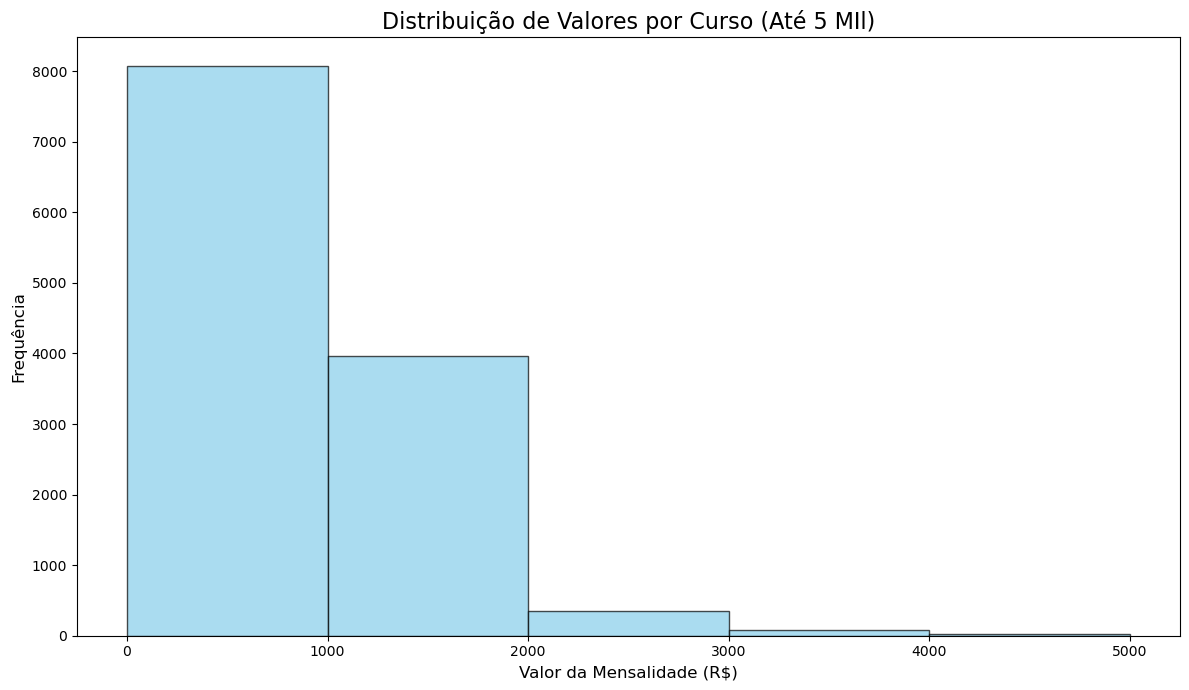

In [36]:

valor_maximo = 5000
df_filtrado = df_unido[(df_unido['mensalidade'] >= 0) & (df_unido['mensalidade'] <= valor_maximo)]

bins = range(0, int(valor_maximo) + 1000, 1000)


df_unico = df_filtrado.drop_duplicates(subset=['nome', 'universidade_nome'])



grafico_histograma = plt.figure(figsize= (12,7))

plt.hist(df_unico['mensalidade'], bins=bins, color= 'skyblue', edgecolor='black', alpha= 0.7)

plt.title('Distribuição de Valores por Curso (Até 5 MIl)', fontsize= 16)
plt.xlabel('Valor da Mensalidade (R$)', fontsize=12)
plt.ylabel('Frequência', fontsize=12)

plt.tight_layout()
plt.show()

histograma = grafico_histograma.get_figure()
histograma.savefig('grafico_histograma.png')



Gráfico de Dispersão (Mensalidade vs. Nota de Corte).

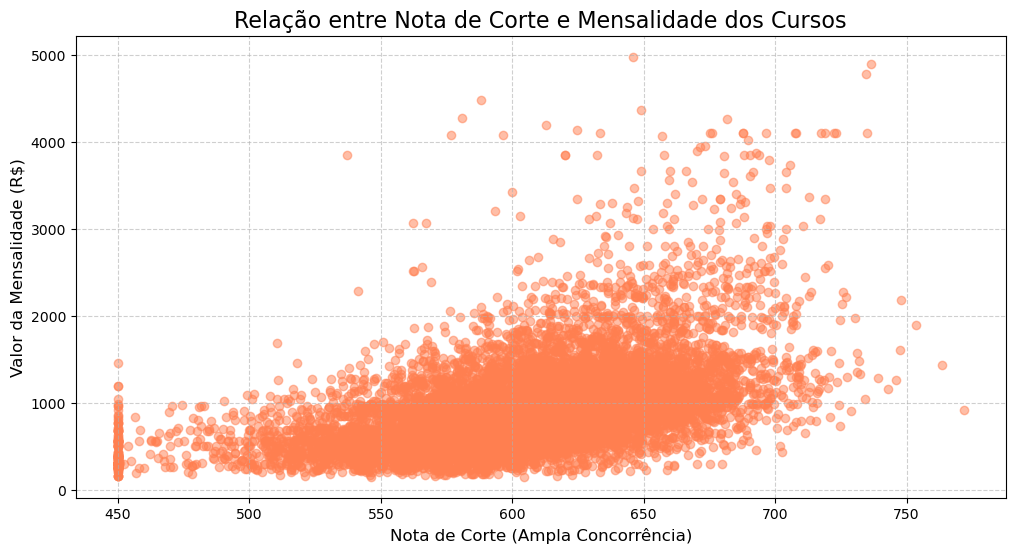

In [37]:
df_dispersao = df_unico[df_unico['nota_integral_ampla'] > 0]

grafico_dispersao = plt.figure(figsize=(12, 6))


plt.scatter(df_dispersao['nota_integral_ampla'], df_dispersao['mensalidade'], alpha=0.5, color='coral')

plt.title('Relação entre Nota de Corte e Mensalidade dos Cursos', fontsize=16)
plt.xlabel('Nota de Corte (Ampla Concorrência)', fontsize=12)
plt.ylabel('Valor da Mensalidade (R$)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)


grafico_dispersao.savefig('grafico_dispersao.png', dpi=300)
plt.show()

•	Missão 3 (Extração de Insights): Usar o .groupby() do Pandas para descobrir a média da nota de corte separada por grau do curso (Licenciatura, Bacharelado, Tecnólogo).

In [38]:
df_notas_validas = df_unido[df_unido['nota_integral_ampla'] > 0]


resumo_graus = (df_notas_validas.groupby('grau', as_index=False)
            .agg(
                Quantidade_Cursos=('grau', 'size'),
                Media_Nota_Corte=('nota_integral_ampla', 'mean')
            ))


resumo_graus['Media_Nota_Corte'] = resumo_graus['Media_Nota_Corte'].round(2)
resumo_graus = resumo_graus.sort_values(by='Media_Nota_Corte', ascending=False)

resumo_graus

,grau,Quantidade_Cursos,Media_Nota_Corte
0,Bacharelado,15911,603.08
1,Licenciatura,6602,557.61
2,Tecnológico,10007,545.01
